Here's a function to subtract the foreground based on color levels. This approach typically involves defining a color range that represents the foreground and then creating a mask to isolate it. You can then use this mask to remove the foreground from the original image or replace it with a background color.

Original Image:


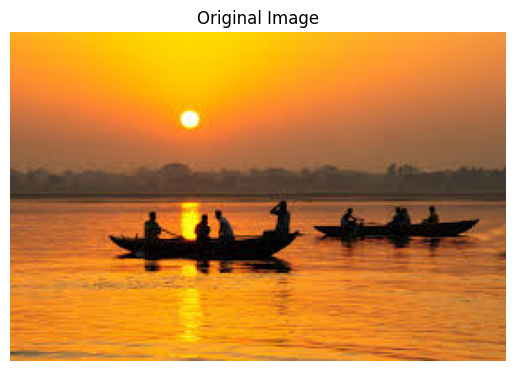

Foreground Subtracted Image:


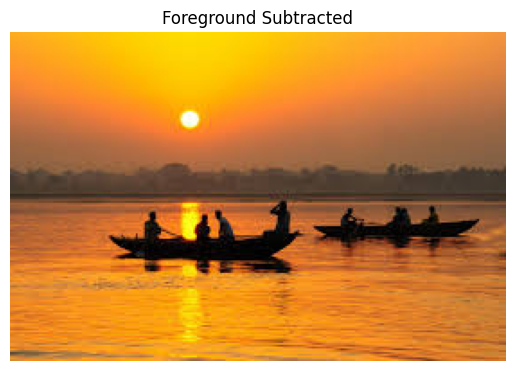

In [1]:
import cv2
import numpy as np

def subtract_foreground_by_color(image_path, lower_color_bound, upper_color_bound, background_color=(0, 0, 0)):
    """
    Subtracts the foreground from an image based on a specified color range.

    Args:
        image_path (str): The path to the input image.
        lower_color_bound (tuple): A tuple (B, G, R) defining the lower bound of the foreground color.
        upper_color_bound (tuple): A tuple (B, G, R) defining the upper bound of the foreground color.
        background_color (tuple): A tuple (B, G, R) representing the color to replace the foreground with.
                                  Defaults to black (0, 0, 0).

    Returns:
        numpy.ndarray: The image with the foreground subtracted.
                       Returns None if the image cannot be loaded.
    """
    # Load the image
    image = cv2.imread(image_path)

    if image is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    # Create a mask for the foreground colors
    # The color bounds are expected in BGR format for OpenCV
    mask = cv2.inRange(image, lower_color_bound, upper_color_bound)

    # Invert the mask to get the background (non-foreground) regions
    # This mask will be 255 for non-foreground and 0 for foreground
    mask_inv = cv2.bitwise_not(mask)

    # Create a blank image of the same size as the original, filled with the background_color
    background = np.full(image.shape, background_color, dtype=np.uint8)

    # Use the inverted mask to copy non-foreground pixels from the original image
    # and combine with the desired background color
    # The foreground regions in the original image will be masked out (0s in mask_inv)
    # and replaced by the background color where mask_inv is 0 (i.e., where foreground was)
    result = cv2.bitwise_and(image, image, mask=mask_inv)

    # Optionally, you can blend the background image in the masked areas.
    # For direct subtraction/replacement, the above 'result' is often sufficient
    # If you want to literally 'subtract' and replace with a solid color where foreground was:
    # result = np.where(mask[:, :, None] == 255, background_color, image)
    # The bitwise operation is generally cleaner for this kind of masking.

    # A more direct way to fill the foreground with background_color:
    # cloned_image = image.copy()
    # cloned_image[mask == 255] = background_color
    # return cloned_image

    return result

# Example usage:
# To run this example, you need an actual image file.
# The color bounds below are examples and will need to be adjusted for 'nature image.jpeg'.

# Path to the user's image
image_path = '/content/nature image.jpeg'

# Load the original image to display it
original_image = cv2.imread(image_path)

if original_image is None:
    print(f"Error: Could not load image from {image_path}. Please ensure the file exists.")
else:
    # Define example color range (these are for a green-screen type scenario, adjust as needed)
    # You will need to find the specific BGR color bounds for the foreground you want to remove
    # in your 'nature image.jpeg'.
    lower_bound = (0, 100, 0)  # Example: lower bound for green (B, G, R)
    upper_bound = (50, 255, 50) # Example: upper bound for green (B, G, R)

    # Specify the desired new background color (e.g., blue)
    new_background_color = (255, 0, 0) # Blue in BGR

    # Call the function
    result_image = subtract_foreground_by_color(image_path, lower_bound, upper_bound, new_background_color)

    if result_image is not None:
        # Display the original and result images using matplotlib
        from matplotlib import pyplot as plt

        print("Original Image:")
        plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
        plt.title('Original Image')
        plt.axis('off')
        plt.show()

        print("Foreground Subtracted Image:")
        plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
        plt.title('Foreground Subtracted')
        plt.axis('off')
        plt.show()


Let's visualize the mask generated based on the current `lower_bound` and `upper_bound` to see what is being detected as foreground.

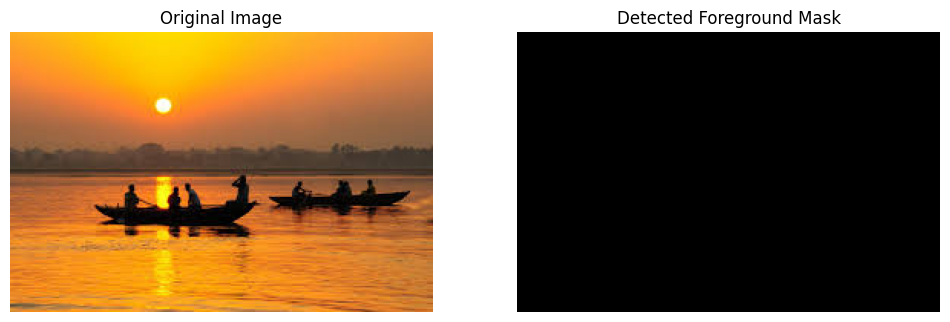

In [2]:
import cv2
from matplotlib import pyplot as plt

# Reuse the image_path and color bounds from previous execution
# image_path = '/content/nature image.jpeg'
# original_image = cv2.imread(image_path)
# lower_bound = (0, 100, 0)
# upper_bound = (50, 255, 50)

# Ensure original_image is loaded in case the previous cell was not run
if 'original_image' not in locals() or original_image is None:
    original_image = cv2.imread(image_path)
    if original_image is None:
        print(f"Error: Could not load image from {image_path}. Please ensure the file exists.")
    else:
        print("Original image reloaded.")

if original_image is not None:
    # Create a mask for the foreground colors using the existing bounds
    mask = cv2.inRange(original_image, lower_bound, upper_bound)

    # Display the original image and the generated mask
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    # Masks are grayscale, so use 'gray' colormap
    plt.imshow(mask, cmap='gray')
    plt.title('Detected Foreground Mask')
    plt.axis('off')

    plt.show()
else:
    print("Cannot display mask because original image could not be loaded.")
